In [1]:
import pandas as pd

df = pd.read_csv("sales_data_with_discounts.csv")

df.head()


,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,C,15,Mobiles,RealU,RU-10,12100,181500,11.654820,21153.498820,160346.501180
1,01-04-2021,Thursday,M02,C,10,Mobiles,RealU,RU-9 Plus,10100,101000,11.560498,11676.102961,89323.897039
2,01-04-2021,Thursday,M03,C,7,Mobiles,YouM,YM-99,16100,112700,9.456886,10657.910157,102042.089843
3,01-04-2021,Thursday,M04,C,6,Mobiles,YouM,YM-99 Plus,20100,120600,6.935385,8364.074702,112235.925298
4,01-04-2021,Thursday,M05,C,3,Mobiles,YouM,YM-98,8100,24300,17.995663,4372.946230,19927.053770


In [2]:
# Check data info
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               450 non-null    object 
 1   Day                450 non-null    object 
 2   SKU                450 non-null    object 
 3   City               450 non-null    object 
 4   Volume             450 non-null    int64  
 5   BU                 450 non-null    object 
 6   Brand              450 non-null    object 
 7   Model              450 non-null    object 
 8   Avg Price          450 non-null    int64  
 9   Total Sales Value  450 non-null    int64  
 10  Discount Rate (%)  450 non-null    float64
 11  Discount Amount    450 non-null    float64
 12  Net Sales Value    450 non-null    float64
dtypes: float64(3), int64(3), object(7)
memory usage: 45.8+ KB


In [3]:
# Descriptive statistics
df.describe()


,Volume,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
count,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000
mean,5.066667,10453.433333,33812.835556,15.155242,3346.499424,30466.336131
std,4.231602,18079.904840,50535.074173,4.220602,4509.902963,46358.656624
min,1.000000,290.000000,400.000000,5.007822,69.177942,326.974801
25%,3.000000,465.000000,2700.000000,13.965063,460.459304,2202.208645
50%,4.000000,1450.000000,5700.000000,16.577766,988.933733,4677.788059
75%,6.000000,10100.000000,53200.000000,18.114718,5316.495427,47847.912852
max,31.000000,60100.000000,196400.000000,19.992407,25738.022194,179507.479049


In [4]:
df.mode()


,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,F01,C,3.0,FMCG,Jeera,Babaji Cream,400.0,24300.0,5.007822,69.177942,326.974801
1,02-04-2021,NaN,F02,NaN,NaN,Lifestyle,NaN,Babaji Oil,450.0,NaN,5.055218,73.025199,330.822058
2,03-04-2021,NaN,F03,NaN,NaN,Mobiles,NaN,Babaji Shampoo,500.0,NaN,5.059801,93.649161,466.350839
3,04-04-2021,NaN,F04,NaN,NaN,NaN,NaN,Gear BB Cream,1300.0,NaN,5.072124,94.682735,485.317265
4,05-04-2021,NaN,F05,NaN,NaN,NaN,NaN,Gear Cream,8100.0,NaN,5.084108,102.705757,496.607104
...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.940610,17900.983733,162603.186379
446,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.965340,21153.498820,163915.971000
447,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.976879,21496.675367,163967.080070
448,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.982257,25328.224204,166263.161348


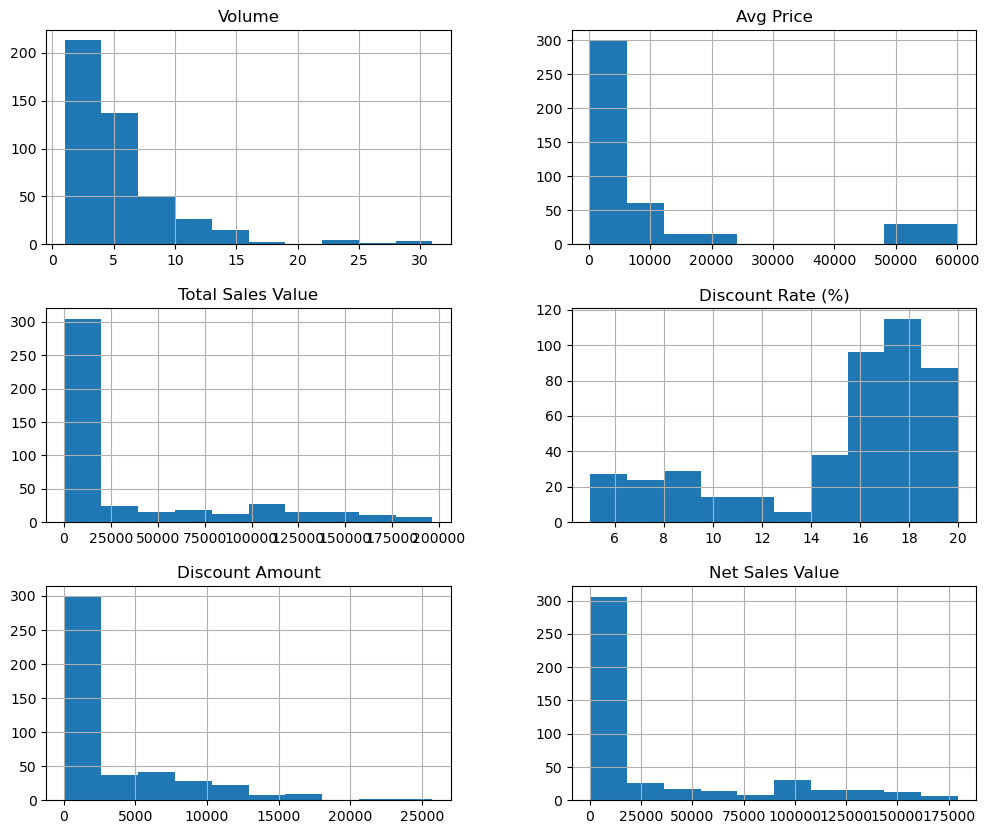

In [5]:
import matplotlib.pyplot as plt

df.hist(figsize=(12,10))
plt.show()


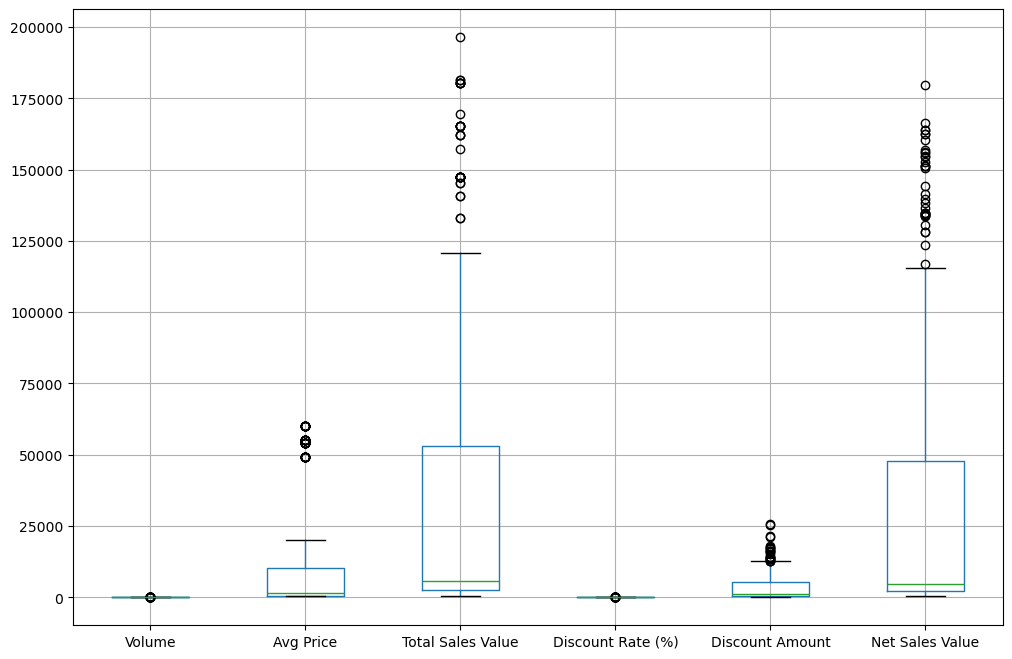

In [6]:
df.boxplot(figsize=(12,8))
plt.show()


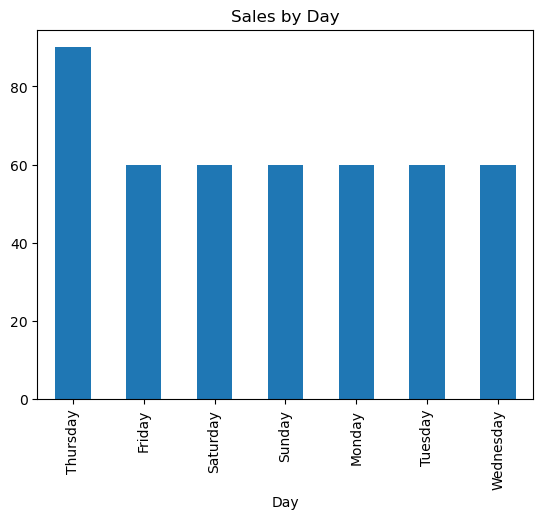

In [7]:
df['Day'].value_counts().plot(kind='bar')
plt.title("Sales by Day")
plt.show()


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = df.select_dtypes(include='number').columns

df_scaled = df.copy()
df_scaled[num_cols] = scaler.fit_transform(df[num_cols])

df_scaled.head()


,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,C,2.350029,Mobiles,RealU,RU-10,0.091173,2.925721,-0.830289,3.952816,2.804756
1,01-04-2021,Thursday,M02,C,1.167129,Mobiles,RealU,RU-9 Plus,-0.019570,1.330995,-0.852661,1.849014,1.271026
2,01-04-2021,Thursday,M03,C,0.457388,Mobiles,YouM,YM-99,0.312659,1.562775,-1.351631,1.622995,1.545675
3,01-04-2021,Thursday,M04,C,0.220808,Mobiles,YouM,YM-99 Plus,0.534146,1.719276,-1.949723,1.113807,1.765810
4,01-04-2021,Thursday,M05,C,-0.488932,Mobiles,YouM,YM-98,-0.130313,-0.188452,0.673739,0.227852,-0.227595


In [9]:
df_encoded = pd.get_dummies(df, drop_first=True)

df_encoded.head()


,Volume,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value,Date_02-04-2021,Date_03-04-2021,Date_04-04-2021,Date_05-04-2021,...,Model_Vedic Cream,Model_Vedic Oil,Model_Vedic Shampoo,Model_W-Casuals,Model_W-Inners,Model_W-Lounge,Model_W-Western,Model_YM-98,Model_YM-99,Model_YM-99 Plus
0,15,12100,181500,11.654820,21153.498820,160346.501180,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,10,10100,101000,11.560498,11676.102961,89323.897039,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,7,16100,112700,9.456886,10657.910157,102042.089843,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,6,20100,120600,6.935385,8364.074702,112235.925298,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,3,8100,24300,17.995663,4372.946230,19927.053770,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [ ]:
CONCLUSION:

In this assignment, descriptive statistics were performed to understand the basic characteristics of the dataset. Data visualization techniques such as histograms, boxplots, and bar charts were used to analyze the distribution and identify outliers. Numerical variables were standardized using Z-score normalization to bring them to a common scale. Categorical variables were converted into dummy variables using one-hot encoding. These preprocessing steps improve the quality of data and make it suitable for machine learning models.